
# TRNG Project



# TRNG Implementation over AVR XMEGA chip

For our implementation we used the AVR XMEGA D4 SoC. The SoC consists of a main CPU and peripherals, the block diagram is described below:

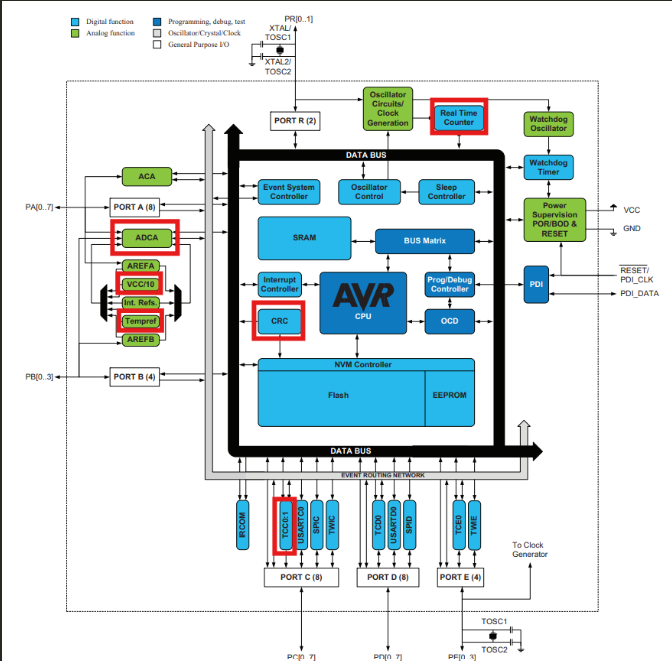

We utilized the blocks circled in red for random number generation.

## RTC - 16-bit Real-Time Counter
This is an RTC module, has a 16-bit resultion of counter.

Has a selectable clock source: 

- 32.768 kHz external crystal
- External clock
- 32.768 kHz internal oscillator
- 32 kHz internal ULP oscillator

Also there is a programmable 10-bit clock prescaling.

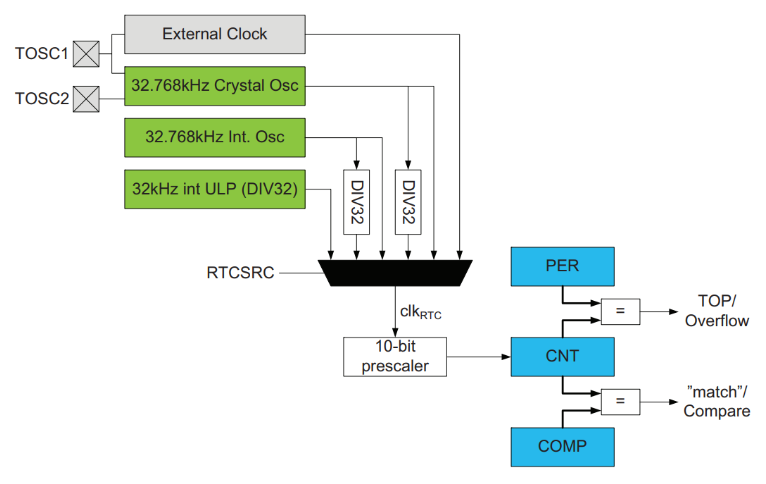

We used the internal 32.768 kHz internal oscillator, without prescaling (divider of 1).

## TCC0 - Timer/Counter
This is a simple timer/counter (much like the RTC).

The TCC0 receives $clk_{PER}$ for counting, It also has internal prescaler for it which we set to divide the clock by 1 (no prescaling).

## Timer based RNG

The clock scheme allows us to choose different clock sources for two different counters:

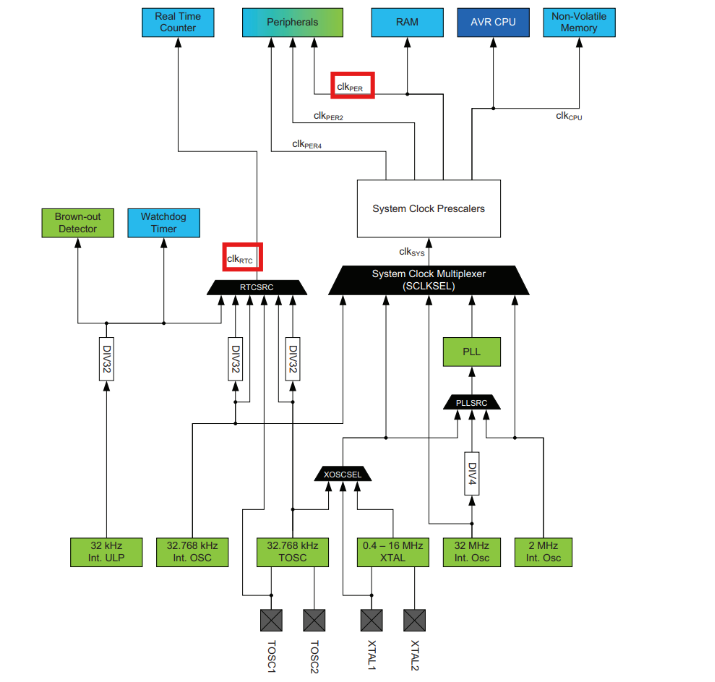

So if we'll configure the two timers to work on different clock sources, we'll be able to take advantage of clock variance like: 

- Jitter
- Differences in the frequency

Since the two clocks will have different variances in run time, if we'll wait a certain amount of time using one of them (e.g., waiting for the RTC to overflow), we would expect variance on the counter value on the second one (e.g. the value of TCC0).

We implemented it by measuring TCC0 counter value (starting from 0) in the time that it takes the RTC to reach specific value. This is the source of randomness in this RNG. 

### cosiderations in clock selection
We have several options for selecting the clk's.
For the TCC we have 3 options (there isnt an external oscillators), so our options are: 
- 32Mhz int osc
- 2Mhz int osc
- 32.768 khz int osc

For the RTC we have 2 options:
- 32khz int ULP osc
- 32.768 khz int osc

We have 5 options excluding the option which is the same oscilator for both timers, for the TCC we want to take the fast clk's(Mhz) since they will provide higher randomness.

We will show the results and decided which configuration is the best in later section.

## ADCA

The ADC in this chip is 12-bit Analog to Digital Convertor, as the high-level chip block diagram showed, it could receive as an input - 

- Tempref
- VCC/10

We wanted to utilize these two into generation of random numbers.

The supply voltage must vary due to noises and all sorts of processes happening in the chip.

The temperature should also vary due to the environment and the processes occuring in the chip.

> Interesting topic for another day is to see if you could deploy side channel attack from within the XMEGA using the VCC/10 input to the ADC.

We utilized both of these and extracted bits from the digital samples as the randomness source.

## CRC

We saw that we have a problem in passing all NIST test(in the TRNG inplimatation that we decided to take eventually), so for more bias reduction and whitenning process, we used CRC algorithm as part of our Random Number Generator to get better results at the NIST test suite. The XMEGA provided a CRC module (hardware implementation) with constant polynomials, so we utilized it for best performance.

The module has 2 configuartions CRC16 and CRC32 , we chose CRC32 which use the next poly - x32+x26+x23+x22+x16+x12+x11+x10+x8+x7+x5+x4+x2+x+1

##  Build firmware

In [561]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 11783055                  to 34779915                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

In [530]:
%%bash
make -C ../src/ PLATFORM=CWLITEXMEGA SS_VER=SS_VER_2_1

make: Entering directory '/mnt/c/Users/alona/ChipWhisperer/chipwhisperer/secure-hardware/TRNG/combined_trng/src'
No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     adc_utils.c ...
-e Done!
.
Compiling:
-en     init.c ...
-e Done!
.
Compiling:
-en     main.c ...
-e Done!
.
Compiling:
-en     reset.c ...
-e Done!
.
Compiling:
-en     rng.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal/hal.c ...
-e Done!
.


##  Program target (XMEGA on CW303)

In [531]:
hex = "../src/build/combined_trng-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4577 bytes


##  Basic check

why the first always falls???????

### restart callback check

In [532]:
import time

target.flush()

# Send reset command
target.simpleserial_write('x', b'')
# Give MCU time to reboot
time.sleep(0.1)
resp = target.read()
if "##BOOT##" in resp:
    print("MCU rebooted OK:", resp)
else:
    print("No BOOT marker seen, got:", resp)




MCU rebooted OK: ÿ##BOOT##× 


### TRNG callback check

In [527]:
# Ask target for that chunk
scmd = 2
want = 10
target.send_cmd('b',scmd,want.to_bytes(1,'little'))

# Read exactly 'want' bytes (no ack check until final)
chunk = target.simpleserial_read('r', want, timeout=2000)
if chunk is None or len(chunk) != want:
    print("Bad block, skipping…")

print("Received", len(chunk), "bytes:", chunk.hex())

Received 10 bytes: 6608b3de03a2212e0e7c


# Collect data & statistics

## classes helpers

In [579]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy, beta

class TRNGAnalyzer:
    def __init__(self, data):
        self.data = np.array(data, dtype=np.uint8)

    # --- Distribution ---
    def byte_distribution(self):
        counts = np.bincount(self.data, minlength=256)
        probs = counts / counts.sum()
        return counts, probs

    def plot_distribution(self, values, probs):
        plt.bar(values, probs)
        plt.axhline(1/256, color='r', linestyle='--', label='Uniform expected')
        plt.xlabel("Byte value (0–255)")
        plt.ylabel("Probability")
        plt.legend()
        plt.title("Distribution of TRNG Byte Values")
        plt.show()

    # --- Autocorrelation ---
    def autocorrelation(self, max_lag=32, skip_zero=True):
        mean = np.mean(self.data)
        norm = self.data - mean
        corr = np.correlate(norm, norm, mode="full")
        corr = corr[corr.size//2:] / corr[corr.size//2]

        if skip_zero:
            lags = np.arange(1, max_lag)
            plt.stem(lags, corr[1:max_lag])
        else:
            lags = np.arange(max_lag)
            plt.stem(lags, corr[:max_lag])

        plt.xlabel("Lag")
        plt.ylabel("Autocorrelation")
        plt.title("Autocorrelation of TRNG Bitstream")
        plt.show()

    # --- Entropy ---
    def entropy_measures(self, alpha=0.01):
        counts, probs = self.byte_distribution()

        H = entropy(probs, base=2)
        p_max = probs.max()
        Hmin = -np.log2(p_max)

        N = counts.sum()
        c_max = counts.max()
        pmax_upper = beta.ppf(1 - alpha, c_max + 1, N - c_max)
        Hmin_lb = -np.log2(pmax_upper)

        print(f"Shannon entropy: {H:.4f} bits/byte (ideal = 8)")
        print(f"Min-entropy (per byte): {Hmin:.4f} bits; p_max = {p_max:.6f}")
        print(f"{100*(1-alpha):.0f}% lower bound Hmin: {Hmin_lb:.4f} bits/byte")

        return {
            "shannon": H,
            "min_entropy": Hmin,
            "min_entropy_lb": Hmin_lb,
            "p_max": p_max
        }

    # --- FFT Analysis ---
    def fft_spectrum(self, bits):
        """Compute FFT on bitstream (0/1) shifted by 0.5 for symmetry"""
        fft_vals = np.fft.fft(bits - 0.5)
        plt.semilogy(np.abs(fft_vals[:len(fft_vals)//2]))
        plt.title("FFT of bitstream (deviation from 0.5)")
        plt.xlabel("Frequency bin")
        plt.ylabel("Magnitude")
        plt.show()

    def bit_bias(self):
        """
        Returns an array of length 8 with P(bit=1) for bit positions 0..7.
        Uses LSB-first convention: bit 0 is the least-significant bit of each byte.
        """
        n = self.data.size
        biases = [np.count_nonzero((self.data >> b) & 1) / n for b in range(8)]
        return np.array(biases)

    def plot_bit_bias(self):
        biases = self.bit_bias()
        plt.bar(range(8), biases)
        plt.axhline(0.5, color='r', linestyle='--', label='ideal = 0.5')
        plt.xticks(range(8), [f"bit {i}" for i in range(8)])
        plt.ylim(0, 0.52)
        plt.ylabel("Probability of 1")
        plt.title("Bit bias per position")
        plt.legend()
        plt.show()



## data collection

In [ ]:
import numpy as np
import time
import logging   

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

name_str = f"1m_bit_random_data_osc_in_firmware_0.5m_sequential"

CHUNK = 10            # safe per-request size
I = 6250
N = I*CHUNK               # total bytes you want
buf = bytearray()
scmd = 0
# Loop until we have N bytes
remaining = N
while remaining > 0:
    print(f"Need {remaining} more bytes…")
    target.flush()
    want = min(CHUNK, remaining)


    # Ask target for that chunk
    target.send_cmd('b',scmd,want.to_bytes(1,'little'))

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=200000)
    if chunk is None or len(chunk) != want:
        print("Bad block, skipping…")
        continue

    buf.extend(chunk)
    remaining -= want


data = np.frombuffer(buf, dtype=np.uint8)
np.save("../data/sequential/"+name_str, data)
# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(data)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\sequential\\"+name_str+".bin")

## statistics

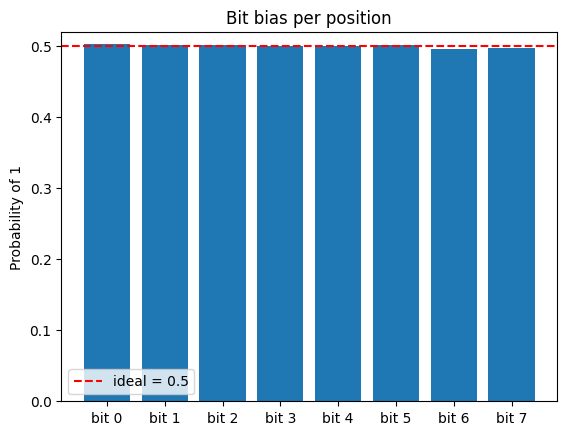

P(1) per bit 0..7: [0.502736 0.501488 0.500928 0.499696 0.499552 0.500848 0.495728 0.496576]


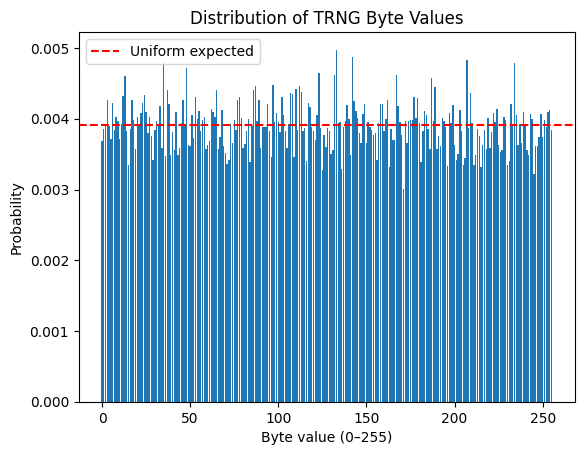

Shannon entropy: 7.9949 bits/byte (ideal = 8)
Min-entropy (per byte): 7.6508 bits; p_max = 0.004976
99% lower bound Hmin: 7.4622 bits/byte


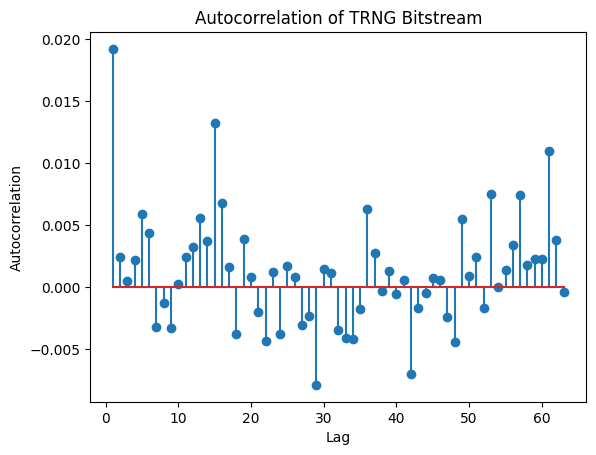

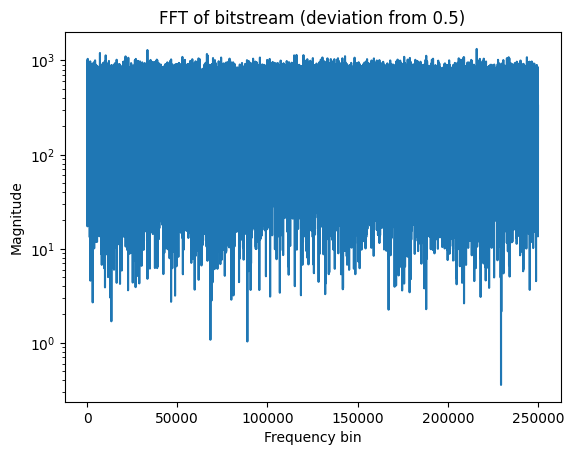

In [ ]:
import numpy as np

# Load your TRNG data (from binary file)
# data = np.fromfile("your_trng_output.bin", dtype=np.uint8)

# Initialize analyzer
analyzer = TRNGAnalyzer(data)

# 1. Distribution

# Plot per-bit bias
analyzer.plot_bit_bias()
# If you also want the raw numbers:
biases = analyzer.bit_bias()
print("P(1) per bit 0..7:", np.round(biases, 6))
# Plot byte distribution
counts, probs = analyzer.byte_distribution()
analyzer.plot_distribution(range(256), probs)

# 2. Entropy
results = analyzer.entropy_measures()

# 3. Autocorrelation
analyzer.autocorrelation(max_lag=64)

# 4. FFT analysis
bits = np.unpackbits(data)
analyzer.fft_spectrum(bits)


Need 62500 more bytes…
Need 62490 more bytes…
Need 62480 more bytes…
Need 62470 more bytes…
Need 62460 more bytes…
Need 62450 more bytes…
Need 62440 more bytes…
Need 62430 more bytes…
Need 62420 more bytes…
Need 62410 more bytes…
Need 62400 more bytes…
Need 62390 more bytes…
Need 62380 more bytes…
Need 62370 more bytes…
Need 62360 more bytes…
Need 62350 more bytes…
Need 62340 more bytes…
Need 62330 more bytes…
Need 62320 more bytes…
Need 62310 more bytes…
Need 62300 more bytes…
Need 62290 more bytes…
Need 62280 more bytes…
Need 62270 more bytes…
Need 62260 more bytes…
Need 62250 more bytes…
Need 62240 more bytes…
Need 62230 more bytes…
Need 62220 more bytes…
Need 62210 more bytes…
Need 62200 more bytes…
Need 62190 more bytes…
Need 62180 more bytes…
Need 62170 more bytes…
Need 62160 more bytes…
Need 62150 more bytes…
Need 62140 more bytes…
Need 62130 more bytes…
Need 62120 more bytes…
Need 62110 more bytes…
Need 62100 more bytes…
Need 62090 more bytes…
Need 62080 more bytes…
Need 62070 

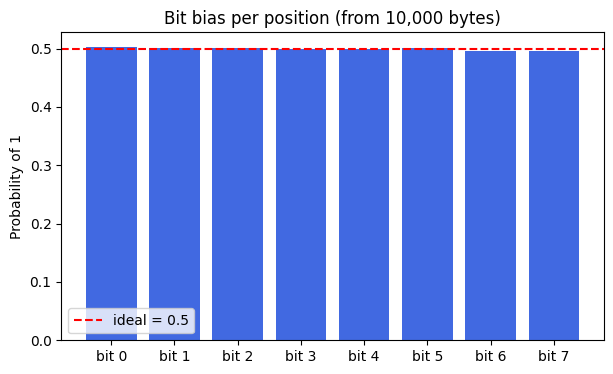


Byte distribution stats:
Min prob: 0.0030, Max prob: 0.0050, Expected = 0.0039


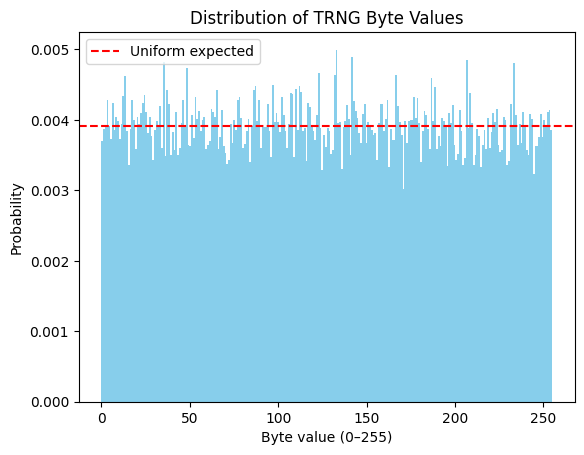

In [ ]:
# ---------- Analysis ----------
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()





In [541]:
from scipy.stats import entropy,beta

H = entropy(probs, base=2)
print(f"Shannon entropy: {H:.4f} bits per byte (ideal = 8)")

p_max = probs.max()
Hmin_byte = -np.log2(p_max)
print(f"Min-entropy (per byte): {Hmin_byte:.4f} bits; p_max={p_max:.6f}")


# Optional: 99% lower bound using counts
N = counts.sum()            # total samples
c_max = counts.max()        # count of most common byte
alpha = 0.01                # 99% confidence
pmax_upper = beta.ppf(1 - alpha, c_max + 1, N - c_max)  # upper bound on p_max
Hmin_lb_byte = -np.log2(pmax_upper)
print(f"99% lower bound H_min (per byte): {Hmin_lb_byte:.4f} bits")

Shannon entropy: 8.0000 bits per byte (ideal = 8)
Min-entropy (per byte): 7.9851 bits; p_max=0.003947
99% lower bound H_min (per byte): 7.9683 bits


Autocorrelation lag 1: 0.000045
Autocorrelation lag 2: 0.000172
Autocorrelation lag 3: -0.000005
Autocorrelation lag 4: -0.000105
Autocorrelation lag 5: -0.000086
Autocorrelation lag 6: -0.000098
Autocorrelation lag 7: 0.000073
Autocorrelation lag 8: -0.000251
Autocorrelation lag 12: 0.000011
Autocorrelation lag 16: 0.000190
Autocorrelation lag 32: -0.000183
Autocorrelation lag 64: -0.000111


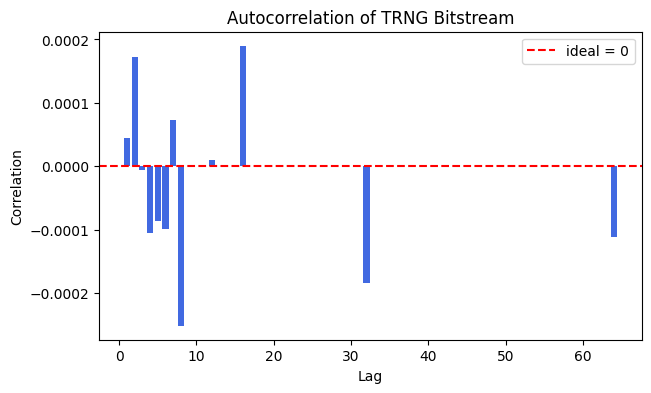

In [543]:
import numpy as np
import matplotlib.pyplot as plt

# Convert bytes → bits (flatten into 0/1 array)
bits = np.unpackbits(data).astype(float)

def autocorr(bits, lag):
    """Compute autocorrelation at a given lag safely."""
    if lag >= len(bits):
        return np.nan
    return np.corrcoef(bits[:-lag], bits[lag:])[0, 1]

# Choose lags to test
lags = [1, 2, 3,4,5,6,7, 8, 12, 16, 32, 64]
results = {}

for lag in lags:
    ac = autocorr(bits, lag)
    results[lag] = ac
    print(f"Autocorrelation lag {lag}: {ac:.6f}")

# --- Plot autocorrelation results ---
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color="royalblue")
plt.axhline(0, color="red", linestyle="--", label="ideal = 0")
plt.ylabel("Correlation")
plt.xlabel("Lag")
plt.title("Autocorrelation of TRNG Bitstream")
plt.legend()
plt.show()


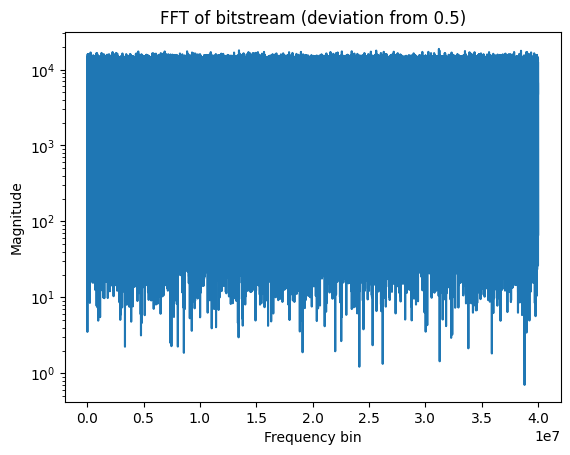

In [545]:
import matplotlib.pyplot as plt

fft_vals = np.fft.fft(bits - 0.5)
plt.semilogy(np.abs(fft_vals[:len(fft_vals)//2]))
plt.title("FFT of bitstream (deviation from 0.5)")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.show()


## restart set

In [562]:
import numpy as np
import logging
import time

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

# Parameters
NUM_TESTS = 400       # how many restart runs
BYTES_PER_SAMPLE = 6250*2 # 1000 bits minimum
CHUNK = 100            # safe per-request size
scmd = 2
name_str = "restart_test_samples_CRC_1byte_100K_per_reset_last_more_400"
all_samples = []

for i in range(NUM_TESTS):
    print(f"[{i+1}/{NUM_TESTS}] collecting...")

    # Periodic reset
    print(">>> Resetting target...")
    target.simpleserial_write('x', b'')   # send reset command
    time.sleep(0.1)                       # give MCU time to reboot
    boot = target.read()
    print("Boot marker:", boot)
 
    buf = bytearray()
    remaining = BYTES_PER_SAMPLE

    while remaining > 0:
        target.flush()   # reset UART buffers
        want = min(CHUNK, remaining)

        # Ask target for that chunk
        target.send_cmd('b', scmd, want.to_bytes(1, 'little'))

        chunk = target.simpleserial_read('r', want, timeout=2000)
        if chunk is None or len(chunk) != want:
            print("Bad block, skipping this sample...")
            continue

        buf.extend(chunk)
        remaining -= want

    # Store if successful
    if buf:
        all_samples.append(np.frombuffer(buf, dtype=np.uint8))

# Save all samples into one .npy file
all_samples = np.array(all_samples, dtype=np.uint8)

np.save("../data/restart/"+name_str, all_samples)
# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(all_samples)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\restart\\"+name_str+".bin")


[1/400] collecting...
>>> Resetting target...
Boot marker:  È%F7BÀ%Nÿ##BOOT##× 
[2/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[3/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[4/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[5/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[6/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[7/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[8/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[9/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[10/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[11/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[12/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[13/400] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[14/400] collecting...
>>> Resetting target...

# NIST RESULTS

In this project we are implementing a True Random Number Generator (TRNG).

There is a need for random number generator in many cryptographic applications. The National Institute of Standards and Technology (NIST) provides a test suite for randomness testing of these generators. This

The NIST test suite consisting of 15 tests that were developed to test the randomness of binary sequences. We'll describe each test. (we'll elaborate on each one).

For the tests we extracted two binary random sequences from our TRNG: 

1. Sequential 1Mbits - no restarts in the middle
2. Restart test - 1024 random bits x 1024 restarts

The result for the sequential tests:

```
------------------------------------------------------------------------------
RESULTS FOR THE UNIFORMITY OF P-VALUES AND THE PROPORTION OF PASSING SEQUENCES
------------------------------------------------------------------------------
   generator is <data/sequential/1m_bit_random_data_crc_in_firmware_1byte_80M_sequential.bin>
------------------------------------------------------------------------------
 C1  C2  C3  C4  C5  C6  C7  C8  C9 C10  P-VALUE  PROPORTION  STATISTICAL TEST
------------------------------------------------------------------------------
  1   1   0   2   2   1   1   1   1   0  0.911413     10/10      Frequency
  0   1   2   0   1   1   1   1   2   1  0.911413     10/10      BlockFrequency
  1   1   1   2   1   3   0   0   1   0  0.534146     10/10      CumulativeSums
  1   2   1   1   0   0   3   1   0   1  0.534146     10/10      CumulativeSums
  0   1   0   1   2   1   0   3   1   1  0.534146     10/10      Runs
  1   0   1   2   2   2   1   1   0   0  0.739918     10/10      LongestRun
  2   0   1   0   1   1   0   1   1   3  0.534146     10/10      Rank
  2   2   1   0   1   1   2   0   1   0  0.739918     10/10      FFT
  1   2   0   1   1   0   2   1   1   1  0.911413     10/10      NonOverlappingTemplate
  1   1   0   0   0   4   0   2   1   1  0.122325      9/10      NonOverlappingTemplate
  2   2   0   0   2   1   0   0   1   2  0.534146      9/10      NonOverlappingTemplate
  1   1   0   2   2   0   2   2   0   0  0.534146     10/10      NonOverlappingTemplate
  2   1   1   0   2   0   2   1   1   0  0.739918     10/10      NonOverlappingTemplate
  3   0   1   1   1   1   0   2   1   0  0.534146      9/10      NonOverlappingTemplate
  0   0   1   1   2   1   1   1   2   1  0.911413     10/10      NonOverlappingTemplate
  1   1   0   0   1   2   2   1   2   0  0.739918     10/10      NonOverlappingTemplate
  2   0   1   2   2   0   1   1   1   0  0.739918      9/10      NonOverlappingTemplate
  0   0   2   1   1   2   1   1   1   1  0.911413     10/10      NonOverlappingTemplate
  2   0   0   2   1   1   0   2   1   1  0.739918     10/10      NonOverlappingTemplate
  0   0   2   1   0   3   1   0   0   3  0.122325     10/10      NonOverlappingTemplate
  1   1   0   0   2   1   2   1   1   1  0.911413     10/10      NonOverlappingTemplate
  1   2   1   0   1   0   1   3   1   0  0.534146     10/10      NonOverlappingTemplate
  0   2   2   1   0   2   1   0   1   1  0.739918     10/10      NonOverlappingTemplate
  0   1   0   3   1   1   0   1   2   1  0.534146     10/10      NonOverlappingTemplate
  1   2   0   3   2   0   0   0   1   1  0.350485     10/10      NonOverlappingTemplate
  1   3   3   0   1   0   1   0   0   1  0.213309     10/10      NonOverlappingTemplate
  0   1   1   1   0   1   1   0   2   3  0.534146     10/10      NonOverlappingTemplate
  0   0   1   1   1   1   3   1   1   1  0.739918     10/10      NonOverlappingTemplate
  1   0   2   1   0   3   0   2   1   0  0.350485     10/10      NonOverlappingTemplate
  0   2   3   1   0   1   0   1   1   1  0.534146     10/10      NonOverlappingTemplate
  0   1   0   0   2   0   2   1   4   0  0.066882     10/10      NonOverlappingTemplate
  0   3   2   0   2   1   0   0   1   1  0.350485     10/10      NonOverlappingTemplate
  5   2   0   0   1   1   0   0   1   0  0.008879     10/10      NonOverlappingTemplate
  2   2   0   2   0   1   0   1   2   0  0.534146     10/10      NonOverlappingTemplate
  0   2   2   2   1   1   1   1   0   0  0.739918     10/10      NonOverlappingTemplate
  0   2   0   1   2   1   1   2   1   0  0.739918     10/10      NonOverlappingTemplate
  2   2   1   0   1   1   0   1   0   2  0.739918      9/10      NonOverlappingTemplate
  0   1   1   1   0   2   1   0   1   3  0.534146     10/10      NonOverlappingTemplate
  0   4   0   0   0   1   1   0   0   4  0.004301     10/10      NonOverlappingTemplate
  2   0   1   1   1   1   1   1   2   0  0.911413     10/10      NonOverlappingTemplate
  0   1   2   0   0   2   2   1   2   0  0.534146     10/10      NonOverlappingTemplate
  0   1   1   0   1   3   1   0   1   2  0.534146     10/10      NonOverlappingTemplate
  1   1   0   0   1   2   2   2   1   0  0.739918     10/10      NonOverlappingTemplate
  2   1   0   1   3   0   1   0   1   1  0.534146     10/10      NonOverlappingTemplate
  1   0   0   2   0   2   1   2   1   1  0.739918     10/10      NonOverlappingTemplate
  2   1   3   0   0   0   0   2   2   0  0.213309     10/10      NonOverlappingTemplate
  0   0   1   1   1   1   2   0   2   2  0.739918     10/10      NonOverlappingTemplate
  0   2   1   3   0   0   0   1   2   1  0.350485     10/10      NonOverlappingTemplate
  2   0   1   4   1   0   2   0   0   0  0.066882     10/10      NonOverlappingTemplate
  1   1   0   1   2   1   1   0   2   1  0.911413     10/10      NonOverlappingTemplate
  1   0   1   0   0   1   2   4   1   0  0.122325     10/10      NonOverlappingTemplate
  2   1   2   2   0   0   1   1   0   1  0.739918     10/10      NonOverlappingTemplate
  0   1   2   1   1   3   1   1   0   0  0.534146     10/10      NonOverlappingTemplate
  0   0   0   1   1   1   2   0   2   3  0.350485     10/10      NonOverlappingTemplate
  1   0   4   0   0   1   2   0   2   0  0.066882      9/10      NonOverlappingTemplate
  1   3   1   1   1   1   2   0   0   0  0.534146     10/10      NonOverlappingTemplate
  2   0   1   3   1   2   0   0   0   1  0.350485     10/10      NonOverlappingTemplate
  1   1   0   2   0   3   2   1   0   0  0.350485      9/10      NonOverlappingTemplate
  0   2   0   0   1   1   2   3   1   0  0.350485     10/10      NonOverlappingTemplate
  1   2   1   0   0   1   1   1   1   2  0.911413     10/10      NonOverlappingTemplate
  3   0   0   0   3   0   0   1   1   2  0.122325     10/10      NonOverlappingTemplate
  1   3   0   0   1   0   1   0   3   1  0.213309      9/10      NonOverlappingTemplate
  2   2   0   1   1   0   0   1   0   3  0.350485     10/10      NonOverlappingTemplate
  2   0   2   1   1   1   1   1   1   0  0.911413     10/10      NonOverlappingTemplate
  0   1   2   1   2   0   1   3   0   0  0.350485     10/10      NonOverlappingTemplate
  0   0   2   2   0   3   0   1   1   1  0.350485     10/10      NonOverlappingTemplate
  2   2   1   1   0   1   2   1   0   0  0.739918      9/10      NonOverlappingTemplate
  1   0   1   1   0   0   0   3   2   2  0.350485     10/10      NonOverlappingTemplate
  0   2   2   0   4   0   1   1   0   0  0.066882     10/10      NonOverlappingTemplate
  2   1   0   2   1   1   0   1   0   2  0.739918     10/10      NonOverlappingTemplate
  1   0   3   0   1   1   0   1   0   3  0.213309      9/10      NonOverlappingTemplate
  1   1   4   0   1   0   0   0   2   1  0.122325     10/10      NonOverlappingTemplate
  0   1   0   0   2   2   1   0   4   0  0.066882     10/10      NonOverlappingTemplate
  0   1   1   2   0   2   1   1   0   2  0.739918     10/10      NonOverlappingTemplate
  5   0   3   1   0   0   0   0   0   1  0.002043      9/10      NonOverlappingTemplate
  1   1   0   1   0   2   0   2   1   2  0.739918     10/10      NonOverlappingTemplate
  2   1   1   1   1   1   0   1   0   2  0.911413     10/10      NonOverlappingTemplate
  0   0   0   2   0   2   1   1   0   4  0.066882     10/10      NonOverlappingTemplate
  0   2   1   0   3   1   2   1   0   0  0.350485     10/10      NonOverlappingTemplate
  0   3   0   1   0   1   1   2   1   1  0.534146     10/10      NonOverlappingTemplate
  1   4   1   0   0   0   1   2   1   0  0.122325     10/10      NonOverlappingTemplate
  0   0   0   1   1   2   2   2   0   2  0.534146     10/10      NonOverlappingTemplate
  1   2   0   1   1   0   2   1   1   1  0.911413     10/10      NonOverlappingTemplate
  1   1   3   1   2   1   0   0   1   0  0.534146     10/10      NonOverlappingTemplate
  2   1   3   0   0   1   2   0   0   1  0.350485     10/10      NonOverlappingTemplate
  0   1   1   3   1   1   1   0   2   0  0.534146     10/10      NonOverlappingTemplate
  1   0   1   1   1   0   1   3   0   2  0.534146     10/10      NonOverlappingTemplate
  1   0   1   0   1   0   1   2   1   3  0.534146     10/10      NonOverlappingTemplate
  0   1   2   1   0   2   0   2   0   2  0.534146     10/10      NonOverlappingTemplate
  1   0   1   2   0   2   0   0   2   2  0.534146     10/10      NonOverlappingTemplate
  0   1   2   0   0   2   0   1   3   1  0.350485     10/10      NonOverlappingTemplate
  1   4   1   0   0   1   2   0   1   0  0.122325     10/10      NonOverlappingTemplate
  4   2   0   0   2   1   1   0   0   0  0.066882     10/10      NonOverlappingTemplate
  0   3   2   0   1   1   1   1   0   1  0.534146     10/10      NonOverlappingTemplate
  0   1   1   1   2   2   0   0   2   1  0.739918     10/10      NonOverlappingTemplate
  0   1   0   2   0   1   3   0   0   3  0.122325     10/10      NonOverlappingTemplate
  3   1   1   1   0   1   1   1   0   1  0.739918     10/10      NonOverlappingTemplate
  2   2   1   0   0   2   0   2   0   1  0.534146     10/10      NonOverlappingTemplate
  1   1   3   0   3   0   1   0   1   0  0.213309     10/10      NonOverlappingTemplate
  0   2   0   2   0   1   0   3   0   2  0.213309     10/10      NonOverlappingTemplate
  2   1   1   0   1   0   0   1   4   0  0.122325     10/10      NonOverlappingTemplate
  2   2   2   0   1   0   1   0   0   2  0.534146     10/10      NonOverlappingTemplate
  1   3   1   2   2   0   0   0   0   1  0.350485     10/10      NonOverlappingTemplate
  2   0   2   1   0   0   3   1   0   1  0.350485     10/10      NonOverlappingTemplate
  0   0   2   0   0   4   0   2   0   2  0.035174     10/10      NonOverlappingTemplate
  1   3   1   0   1   1   1   0   0   2  0.534146     10/10      NonOverlappingTemplate
  0   1   1   1   0   1   1   2   3   0  0.534146     10/10      NonOverlappingTemplate
  2   0   2   2   1   0   0   0   2   1  0.534146     10/10      NonOverlappingTemplate
  1   3   2   0   1   1   2   0   0   0  0.350485     10/10      NonOverlappingTemplate
  0   2   0   0   2   0   1   1   2   2  0.534146     10/10      NonOverlappingTemplate
  0   0   2   2   3   1   0   1   1   0  0.350485     10/10      NonOverlappingTemplate
  4   1   0   0   0   0   1   2   1   1  0.122325     10/10      NonOverlappingTemplate
  0   1   1   0   2   1   2   1   0   2  0.739918     10/10      NonOverlappingTemplate
  0   0   1   1   1   2   2   0   2   1  0.739918     10/10      NonOverlappingTemplate
  1   1   0   2   1   3   2   0   0   0  0.350485     10/10      NonOverlappingTemplate
  1   2   0   0   2   1   1   3   0   0  0.350485     10/10      NonOverlappingTemplate
  0   0   1   1   0   1   1   5   1   0  0.017912     10/10      NonOverlappingTemplate
  1   1   2   0   1   1   3   0   0   1  0.534146     10/10      NonOverlappingTemplate
  1   0   3   2   1   0   0   1   1   1  0.534146     10/10      NonOverlappingTemplate
  2   1   0   1   1   1   1   2   0   1  0.911413      9/10      NonOverlappingTemplate
  0   1   2   1   1   1   2   1   0   1  0.911413     10/10      NonOverlappingTemplate
  0   0   1   2   0   3   2   0   1   1  0.350485     10/10      NonOverlappingTemplate
  1   0   3   0   2   1   2   1   0   0  0.350485     10/10      NonOverlappingTemplate
  1   2   1   1   1   2   0   0   1   1  0.911413      9/10      NonOverlappingTemplate
  3   1   1   3   0   2   0   0   0   0  0.122325     10/10      NonOverlappingTemplate
  0   1   2   2   0   0   2   1   1   1  0.739918     10/10      NonOverlappingTemplate
  1   3   2   2   0   0   1   0   1   0  0.350485     10/10      NonOverlappingTemplate
  2   2   2   1   0   0   0   1   0   2  0.534146     10/10      NonOverlappingTemplate
  2   1   2   0   1   1   0   1   2   0  0.739918     10/10      NonOverlappingTemplate
  0   1   4   1   0   1   1   0   1   1  0.213309     10/10      NonOverlappingTemplate
  1   1   1   1   0   2   0   2   2   0  0.739918     10/10      NonOverlappingTemplate
  2   2   2   0   1   2   0   1   0   0  0.534146      9/10      NonOverlappingTemplate
  1   1   0   0   3   2   1   1   1   0  0.534146      9/10      NonOverlappingTemplate
  0   1   0   2   2   1   0   1   1   2  0.739918     10/10      NonOverlappingTemplate
  1   0   0   2   1   2   2   1   0   1  0.739918     10/10      NonOverlappingTemplate
  3   2   1   0   0   0   2   1   1   0  0.350485     10/10      NonOverlappingTemplate
  1   1   1   0   0   1   2   0   1   3  0.534146     10/10      NonOverlappingTemplate
  2   1   1   0   0   3   0   0   3   0  0.122325      9/10      NonOverlappingTemplate
  1   1   2   1   0   0   2   1   2   0  0.739918      9/10      NonOverlappingTemplate
  4   3   1   0   0   2   0   0   0   0  0.017912      9/10      NonOverlappingTemplate
  1   2   1   0   2   0   1   1   2   0  0.739918     10/10      NonOverlappingTemplate
  0   1   1   1   2   2   0   0   1   2  0.739918     10/10      NonOverlappingTemplate
  2   1   3   2   0   1   0   0   0   1  0.350485     10/10      NonOverlappingTemplate
  1   2   3   0   0   1   1   0   2   0  0.350485     10/10      NonOverlappingTemplate
  1   1   2   0   3   0   0   0   1   2  0.350485     10/10      NonOverlappingTemplate
  2   0   0   1   0   1   2   1   3   0  0.350485      9/10      NonOverlappingTemplate
  0   3   2   0   0   2   1   1   0   1  0.350485     10/10      NonOverlappingTemplate
  2   1   1   1   1   0   1   3   0   0  0.534146     10/10      NonOverlappingTemplate
  2   3   0   0   2   1   0   0   2   0  0.213309     10/10      NonOverlappingTemplate
  1   1   1   1   0   0   3   2   1   0  0.534146      9/10      NonOverlappingTemplate
  1   0   0   4   0   0   1   0   1   3  0.035174     10/10      NonOverlappingTemplate
  0   0   3   2   1   0   3   0   1   0  0.122325     10/10      NonOverlappingTemplate
  0   1   1   0   2   1   2   0   2   1  0.739918     10/10      NonOverlappingTemplate
  1   0   1   2   0   1   0   2   3   0  0.350485     10/10      NonOverlappingTemplate
  0   3   0   1   2   0   1   1   1   1  0.534146     10/10      NonOverlappingTemplate
  0   0   0   1   1   2   2   2   0   2  0.534146     10/10      NonOverlappingTemplate
  1   3   2   1   1   0   0   1   0   1  0.534146     10/10      OverlappingTemplate
  1   1   0   1   3   0   3   0   1   0  0.213309     10/10      Universal
  1   1   1   0   0   1   3   1   0   2  0.534146     10/10      ApproximateEntropy
  1   0   0   1   1   1   2   2   1   0     ----       9/9       RandomExcursions
  0   1   2   1   0   0   1   1   2   1     ----       9/9       RandomExcursions
  1   1   2   0   0   2   1   1   1   0     ----       9/9       RandomExcursions
  1   1   4   1   0   0   0   0   1   1     ----       9/9       RandomExcursions
  1   0   1   0   3   1   1   1   1   0     ----       9/9       RandomExcursions
  0   2   3   0   0   0   0   0   3   1     ----       9/9       RandomExcursions
  1   0   0   0   1   1   0   1   2   3     ----       9/9       RandomExcursions
  2   1   0   0   1   2   2   0   1   0     ----       9/9       RandomExcursions
  0   3   1   0   1   1   0   0   1   2     ----       9/9       RandomExcursionsVariant
  0   1   2   1   0   1   2   1   0   1     ----       9/9       RandomExcursionsVariant
  0   1   1   1   2   3   0   0   1   0     ----       9/9       RandomExcursionsVariant
  0   3   2   2   0   1   0   0   0   1     ----       9/9       RandomExcursionsVariant
  3   0   1   3   1   0   0   0   0   1     ----       9/9       RandomExcursionsVariant
  2   1   2   1   0   0   1   0   0   2     ----       8/9       RandomExcursionsVariant
  2   1   0   1   1   2   0   1   1   0     ----       8/9       RandomExcursionsVariant
  1   3   1   0   1   0   2   0   1   0     ----       9/9       RandomExcursionsVariant
  1   1   1   2   1   0   0   2   0   1     ----       9/9       RandomExcursionsVariant
  2   0   1   1   0   0   2   3   0   0     ----       9/9       RandomExcursionsVariant
  1   1   0   1   0   3   0   1   0   2     ----       8/9       RandomExcursionsVariant
  1   1   1   0   1   1   2   1   0   1     ----       9/9       RandomExcursionsVariant
  1   1   1   1   1   1   0   0   1   2     ----       9/9       RandomExcursionsVariant
  1   2   0   0   0   3   0   1   0   2     ----       9/9       RandomExcursionsVariant
  2   0   2   0   2   0   0   0   2   1     ----       9/9       RandomExcursionsVariant
  1   2   2   1   0   0   0   0   2   1     ----       8/9       RandomExcursionsVariant
  1   1   4   0   0   1   2   0   0   0     ----       8/9       RandomExcursionsVariant
  1   2   1   2   2   1   0   0   0   0     ----       8/9       RandomExcursionsVariant
  2   1   0   1   0   3   0   3   0   0  0.122325     10/10      Serial
  1   1   0   2   0   1   3   1   0   1  0.534146     10/10      Serial
  0   1   1   3   1   0   1   0   0   3  0.213309     10/10      LinearComplexity


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
The minimum pass rate for each statistical test with the exception of the
random excursion (variant) test is approximately = 8 for a
sample size = 10 binary sequences.

The minimum pass rate for the random excursion (variant) test
is approximately = 8 for a sample size = 9 binary sequences.

For further guidelines construct a probability table using the MAPLE program
provided in the addendum section of the documentation.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
```

The result for the restart test are as follows:

```
------------------------------------------------------------------------------
RESULTS FOR THE UNIFORMITY OF P-VALUES AND THE PROPORTION OF PASSING SEQUENCES
------------------------------------------------------------------------------
   generator is <data/restart/restart_test_samples_CRC_1byte_100K_per_reset_last.bin>
------------------------------------------------------------------------------
 C1  C2  C3  C4  C5  C6  C7  C8  C9 C10  P-VALUE  PROPORTION  STATISTICAL TEST
------------------------------------------------------------------------------
111  97  97 103  97 102 101  90 104  98  0.971006    991/1000    Frequency
100  94  97 111  92  99 113  96 107  91  0.792508    990/1000    BlockFrequency
113  96  89 114 112  96  99 101  79 101  0.271619    992/1000    CumulativeSums
108  89 105 114  94  95  94 110  88 103  0.579021    993/1000    CumulativeSums
 93 122 104 104  81 103  95  93 108  97  0.288249    994/1000    Runs
 92 108 100 114 105  94  92  94 105  96  0.811080    989/1000    LongestRun
 85 120  81  98  94 108 124  97 114  79  0.005932    987/1000    Rank
121  91  94  99  95  86 118 112  99  85  0.098330    992/1000    FFT
123  92  79 101  93 102 104 101  96 109  0.212184    982/1000    NonOverlappingTemplate
 98 105  92 105  91 101 117  97 101  93  0.790621    992/1000    NonOverlappingTemplate
118  96 106 112 101  95  90 102  91  89  0.482707    988/1000    NonOverlappingTemplate
 88  98 104 112  97 113  96  92 110  90  0.568739    990/1000    NonOverlappingTemplate
105  89 110 106  96  80 104  88 119 103  0.197981    983/1000    NonOverlappingTemplate
101 114 100 100 100 104 100  81  92 108  0.635037    988/1000    NonOverlappingTemplate
 94  83 104 123  87 107 117 102  91  92  0.084037    988/1000    NonOverlappingTemplate
110 103  91 105 128  77 104 111  89  82  0.012214    987/1000    NonOverlappingTemplate
111  92  98  97  94 124  96 100  99  89  0.394195    989/1000    NonOverlappingTemplate
108  93  90  94 107 103  95  95 110 105  0.849708    991/1000    NonOverlappingTemplate
101  83 103  78 103  93 102 110 114 113  0.158133    985/1000    NonOverlappingTemplate
103  84  96 101 113 115 105  84 108  91  0.274341    986/1000    NonOverlappingTemplate
109  91 118 107  96  97  92 106 101  83  0.392456    988/1000    NonOverlappingTemplate
112  99  88  90  95  93 106 118 101  98  0.506194    990/1000    NonOverlappingTemplate
 76 109 114 107 115  88 100 119  85  87  0.016374    992/1000    NonOverlappingTemplate
 99  95  89 115  97  80 103 103 118 101  0.259616    990/1000    NonOverlappingTemplate
109 103 104 112  98  98  91 107  87  91  0.701366    991/1000    NonOverlappingTemplate
 96  96 101  93  90  94  99 108 124  99  0.474986    987/1000    NonOverlappingTemplate
 97 101  84  96 114 115 112  93  87 101  0.299736    990/1000    NonOverlappingTemplate
 98 108 107 106  95  83 113  92  95 103  0.601766    987/1000    NonOverlappingTemplate
 99  87  90  96  99 104  93 109 101 122  0.420827    989/1000    NonOverlappingTemplate
 93  95 114 111  92  97 107  78  97 116  0.180568    986/1000    NonOverlappingTemplate
 97 112  89 119 103 101 102  96  86  95  0.450297    991/1000    NonOverlappingTemplate
108  99  97 117 101 101  90 111 100  76  0.235589    993/1000    NonOverlappingTemplate
 94 114  98 119 110 112  93  76  95  89  0.064418    988/1000    NonOverlappingTemplate
105  90  93 105 119  97  85 112  97  97  0.387264    982/1000    NonOverlappingTemplate
 93  99 104 107 100 114  92 103 102  86  0.755819    995/1000    NonOverlappingTemplate
 93 110 101 106 107  92 104 109  74 104  0.284024    992/1000    NonOverlappingTemplate
106  97  88 108 119  85  99 103 101  94  0.450297    988/1000    NonOverlappingTemplate
100  99 102  96  92 109  85 110  95 112  0.678686    987/1000    NonOverlappingTemplate
109  90 106  95 104  98 109 102  97  90  0.870856    994/1000    NonOverlappingTemplate
102  94  93  92 101 105 101 104  92 116  0.820143    988/1000    NonOverlappingTemplate
 94 100  98 108  92 111 104 115  88  90  0.560545    986/1000    NonOverlappingTemplate
106  84 106 101 120  78  90 117  95 103  0.059734    984/1000    NonOverlappingTemplate
 76 106  86 102 104 121 103 104  89 109  0.092041    990/1000    NonOverlappingTemplate
 81  87 110 117  94 110 110 102  99  90  0.181557    992/1000    NonOverlappingTemplate
100 103 101 101  94  89 118 115 105  74  0.116065    986/1000    NonOverlappingTemplate
 96 100  96  97 110 102 103  90 110  96  0.930026    984/1000    NonOverlappingTemplate
104 101 108  80 106 102  85  94 111 109  0.363593    986/1000    NonOverlappingTemplate
 92 101 109 106  96 100 101 101  85 109  0.829047    993/1000    NonOverlappingTemplate
 96 106  92  97 112 102 100  92 109  94  0.872425    982/1000    NonOverlappingTemplate
112 101 117  85 110  86 102  89 104  94  0.254411    987/1000    NonOverlappingTemplate
 86 108 118 106 113 101 110 100  90  68  0.017068    991/1000    NonOverlappingTemplate
117  87 104 107  96  94 101  87 112  95  0.424453    987/1000    NonOverlappingTemplate
114  98 106 104  78 103 103  99 104  91  0.482707    989/1000    NonOverlappingTemplate
108 109  97  80  93  98  97 101  99 118  0.399442    986/1000    NonOverlappingTemplate
107 106 109  97 104  89  74  90 110 114  0.128132    989/1000    NonOverlappingTemplate
 91  83  85 103 107 101  97 111 120 102  0.220159    993/1000    NonOverlappingTemplate
 97  88  88 107 123 111  91  98 101  96  0.277082    992/1000    NonOverlappingTemplate
100 102  86 112 103 109  95 102  99  92  0.809249    991/1000    NonOverlappingTemplate
102  98  93 104  89 105 110  86 107 106  0.739918    990/1000    NonOverlappingTemplate
 97 104 107 102  84 109 100 102 101  94  0.870856    988/1000    NonOverlappingTemplate
 94 103 105  93  95 110 101  95  99 105  0.965860    992/1000    NonOverlappingTemplate
 98 107  95 103 121  87  91  95 107  96  0.467322    987/1000    NonOverlappingTemplate
 95  93  87  94 105 115  94 113 102 102  0.593478    989/1000    NonOverlappingTemplate
107  97 104  94 102 117  97  89 110  83  0.417219    988/1000    NonOverlappingTemplate
116 102  93 101 106  83  97  91  99 112  0.465415    989/1000    NonOverlappingTemplate
120  80  87  93 106  97 120 113  93  91  0.039847    992/1000    NonOverlappingTemplate
 97 108 104  90  99 107  87  97 112  99  0.777265    987/1000    NonOverlappingTemplate
 91 113  81  99 112 106 101 109  92  96  0.388990    991/1000    NonOverlappingTemplate
101  91 103  88 107 115  93  93  97 112  0.574903    992/1000    NonOverlappingTemplate
107 108 102  92 108  84 109  97  94  99  0.711601    989/1000    NonOverlappingTemplate
102  99 100  85 115 113  84  98 101 103  0.442831    995/1000    NonOverlappingTemplate
106  97  91 100 102 101  98 100 103 102  0.997292    984/1000    NonOverlappingTemplate
 80  94 106  98  98 107 103  99 105 110  0.674543    996/1000    NonOverlappingTemplate
 99  92  97 119  88 101 104 105  94 101  0.680755    993/1000    NonOverlappingTemplate
 93  93 111 103  88  99 112  99  86 116  0.375313    990/1000    NonOverlappingTemplate
 88 100 108 113  93  93 118 101 103  83  0.277082    989/1000    NonOverlappingTemplate
103 110  82  94 112  95  90  95 117 102  0.307077    991/1000    NonOverlappingTemplate
117 100  92  93  92  92 109 101 100 104  0.711601    991/1000    NonOverlappingTemplate
100 108 102  80  87  99 105  95 114 110  0.363593    988/1000    NonOverlappingTemplate
101 103  98  97 105 104  96 111  98  87  0.927677    989/1000    NonOverlappingTemplate
 86  88 109 101  82 108 110  99 107 110  0.304126    989/1000    NonOverlappingTemplate
108  77  99 120  92 113 100 102  92  97  0.160805    991/1000    NonOverlappingTemplate
124  92  77 101  93 103 104 101  95 110  0.133404    982/1000    NonOverlappingTemplate
107 102  99  80  99  95 110  98 115  95  0.500279    983/1000    NonOverlappingTemplate
102 113  89 101  95  98 104 105  92 101  0.890582    987/1000    NonOverlappingTemplate
 85  90  99 114 108  88  92 114 115  95  0.191687    989/1000    NonOverlappingTemplate
 98  92 114 103 102  88 103  91 107 102  0.775337    993/1000    NonOverlappingTemplate
107  90  94  88  86 108  98 109 114 106  0.431754    989/1000    NonOverlappingTemplate
 97  80  93 105  96 107 105 105 114  98  0.536163    994/1000    NonOverlappingTemplate
104 107 107  84 107  98  95 105  95  98  0.832561    988/1000    NonOverlappingTemplate
 99 109 106  95 107 102  91 102  91  98  0.932333    991/1000    NonOverlappingTemplate
103  84 122 108  92 101 111  95  89  95  0.230755    991/1000    NonOverlappingTemplate
106 101 104  92  98  97  91 114  96 101  0.894918    988/1000    NonOverlappingTemplate
 99 110  91  98 104  94  88 107 105 104  0.858002    988/1000    NonOverlappingTemplate
 99  98 110 105  98 109  90 100 100  91  0.914025    989/1000    NonOverlappingTemplate
 99 100 100 106 106  93 102  90 101 103  0.984415    992/1000    NonOverlappingTemplate
 93 107  97 101  98  96 112 114  94  88  0.691081    991/1000    NonOverlappingTemplate
 95  86  87  96 110 104  92 113 112 105  0.415422    994/1000    NonOverlappingTemplate
 94  91  90  83 128  96 110 102 114  92  0.053627    990/1000    NonOverlappingTemplate
115 104  94 112  90  92  85  93  96 119  0.193767    986/1000    NonOverlappingTemplate
105 108  95  96 103 106 101  92  89 105  0.920383    990/1000    NonOverlappingTemplate
 99  93  88 106  94  99 107 109 107  98  0.875539    991/1000    NonOverlappingTemplate
109  82 107  93 100 106  96 111  91 105  0.552383    990/1000    NonOverlappingTemplate
104 106  94 100  95  88  97 102 106 108  0.930026    989/1000    NonOverlappingTemplate
 93  95 125 104 114  90 109 101  91  78  0.055714    993/1000    NonOverlappingTemplate
104  85  97 102  84 118  96 110  98 106  0.358641    991/1000    NonOverlappingTemplate
105 108  84 107 108 106 100  93  92  97  0.723804    990/1000    NonOverlappingTemplate
101 117  82  99  87 115  93 111  91 104  0.173770    990/1000    NonOverlappingTemplate
 95  83  91 104 101 116 113  91 109  97  0.344048    991/1000    NonOverlappingTemplate
115  94  94  96  90 116 109 104 103  79  0.204439    984/1000    NonOverlappingTemplate
 85  99 103 110  96  96 114 104  99  94  0.723804    992/1000    NonOverlappingTemplate
 95 113  96  89 102  94 113  96 100 102  0.779188    992/1000    NonOverlappingTemplate
109  98 106  94 112  96  91  95 106  93  0.827279    989/1000    NonOverlappingTemplate
 97 100  98 105 108 105 103  94  92  98  0.983453    990/1000    NonOverlappingTemplate
 98  92 105  96 105 102  93  93 103 113  0.901959    992/1000    NonOverlappingTemplate
 98  90 103  88  94 114  92 106 119  96  0.378705    983/1000    NonOverlappingTemplate
124 107 102  88  83  98 110 105  95  88  0.137282    976/1000 *  NonOverlappingTemplate
 93 108  97  93  99  96  99 100 106 109  0.961869    984/1000    NonOverlappingTemplate
 99 106  97 103  92  94  98 115  98  98  0.916599    989/1000    NonOverlappingTemplate
 91  84 106  98 102 104 108 101  89 117  0.463512    990/1000    NonOverlappingTemplate
 91  93 108  85 102 114  89 115 109  94  0.288249    994/1000    NonOverlappingTemplate
 84  93  89 104 118  89  97 112 112 102  0.220159    990/1000    NonOverlappingTemplate
101 106  92 100 103 108 105  89  88 108  0.809249    992/1000    NonOverlappingTemplate
105  97  86 101  92 103 118 104  88 106  0.510153    989/1000    NonOverlappingTemplate
114  97  95 114  95  94  95 109  84 103  0.476911    990/1000    NonOverlappingTemplate
115  94 102  97 114 113  82  89  85 109  0.125927    985/1000    NonOverlappingTemplate
104 100 104  99  89 103 104  91  99 107  0.960198    987/1000    NonOverlappingTemplate
 89 114 102  85 109 105  97  92  94 113  0.410055    990/1000    NonOverlappingTemplate
 86  89  81  99 105 102 111 111  94 122  0.099513    993/1000    NonOverlappingTemplate
 99 105  99 108 102 102 112  86  98  89  0.775337    986/1000    NonOverlappingTemplate
106  98  96 102 103 103  96  92 107  97  0.988677    988/1000    NonOverlappingTemplate
 94  96 104  99 103 110  94  94  94 112  0.890582    987/1000    NonOverlappingTemplate
106  97 118 101  91  98  91 105 111  82  0.345650    988/1000    NonOverlappingTemplate
118  87 100  99 118 115  99  89  90  85  0.093720    986/1000    NonOverlappingTemplate
 85 110  96  96 104 116 101 110  90  92  0.442831    995/1000    NonOverlappingTemplate
105  93  92 109  85 102  95 105 109 105  0.735908    993/1000    NonOverlappingTemplate
103  91  90  91 108 107  93  98 116 103  0.635037    988/1000    NonOverlappingTemplate
122  96  92 102 101  90  86 109 110  92  0.268917    987/1000    NonOverlappingTemplate
 99 107 116  77 112 105  86  98  92 108  0.148653    994/1000    NonOverlappingTemplate
 98 100  82  93 118 107 100  94 109  99  0.467322    993/1000    NonOverlappingTemplate
 79  98 102  86  94 119 106 103  95 118  0.110083    993/1000    NonOverlappingTemplate
 84  95 104 116  84 105  88  94  99 131  0.019453    999/1000    NonOverlappingTemplate
 95 121 101  82  94  98 104  94 112  99  0.328297    991/1000    NonOverlappingTemplate
112  98 109 107  87  99  71 105  99 113  0.095426    986/1000    NonOverlappingTemplate
110  99  93 123  99 102  93  93  95  93  0.478839    986/1000    NonOverlappingTemplate
106  86 105  92  96 112 107  97 104  95  0.759756    990/1000    NonOverlappingTemplate
 85 104  96  98 106 108  98 100  88 117  0.536163    990/1000    NonOverlappingTemplate
102 100  88 104  99 110  91 113  99  94  0.786830    987/1000    NonOverlappingTemplate
 98 104  90  92 104  99 100 107 109  97  0.946308    990/1000    NonOverlappingTemplate
104  93  99  99 106  99  89 104  99 108  0.961869    988/1000    NonOverlappingTemplate
 99 105  99  85 106 103  94 112  95 102  0.829047    987/1000    NonOverlappingTemplate
 95  93  94 104  95 105  98 114 101 101  0.925287    991/1000    NonOverlappingTemplate
 89 103 105  82 106  99  96 105 117  98  0.484646    985/1000    NonOverlappingTemplate
 96 114  91 105  89  91 100 111 111  92  0.508172    992/1000    NonOverlappingTemplate
109  84 101 102 116  95  92 109 100  92  0.502247    990/1000    NonOverlappingTemplate
107  80  98 118  95 110 102 102  91  97  0.350485    991/1000    NonOverlappingTemplate
 90 104  90  89  92 108 119 117 109  82  0.085587    996/1000    OverlappingTemplate
1000   0   0   0   0   0   0   0   0   0  0.000000 *    0/1000 *  Universal
116 126  92  99  96 111 104  81  96  79  0.019993    989/1000    ApproximateEntropy
 10   9  10  11  13  12   9   9  16  16  0.712343    113/115     RandomExcursions
 11   9  14  11  13  11  11  13   7  15  0.849861    113/115     RandomExcursions
 12  13   7  12  11  20   9   9  11  11  0.343176    113/115     RandomExcursions
 11  12   9  14   8  16   7  11  11  16  0.525011    115/115     RandomExcursions
 12  15  11   7  18  10  14  11  12   5  0.229125    112/115     RandomExcursions
 14   8  12  11  11  11   8  11  13  16  0.818179    113/115     RandomExcursions
 10   7  16  13  10  11  19   4   8  17  0.028469    112/115     RandomExcursions
  9  17   8  10  10  10  12  21  10   8  0.096053    114/115     RandomExcursions
  7  13  14  12  11  14   9   9  11  16  0.684327    114/116     RandomExcursionsVariant
  8   9  18  19   9   8  11   8   9  17  0.047311    115/116     RandomExcursionsVariant
 10  12  16  14  11   8  10  13   8  14  0.721592    115/116     RandomExcursionsVariant
 11  14  13  16  10   9   8  11  12  12  0.842160    115/116     RandomExcursionsVariant
 13   9  13  16   9   9  12  10  14  11  0.826313    115/116     RandomExcursionsVariant
 11  13   8  14   8  15  11   9  13  14  0.757969    115/116     RandomExcursionsVariant
 13  10  10  10  13  14  11   9  12  14  0.960581    116/116     RandomExcursionsVariant
 10  14  10   8  11  19   5  16  14   9  0.109965    115/116     RandomExcursionsVariant
  8   8  11  10  15  12  16  10  14  12  0.684327    115/116     RandomExcursionsVariant
 11  10  14  13  12   8   9  13  17   9  0.684327    116/116     RandomExcursionsVariant
 12   9  10  14  12  12  19   5   8  15  0.166763    116/116     RandomExcursionsVariant
  9  18  10  12  16   6  10  12   7  16  0.143094    116/116     RandomExcursionsVariant
 15  13  14  11  10   9  13   9  14   8  0.793022    116/116     RandomExcursionsVariant
 14  17  15   8   9  11  13   9  12   8  0.497956    115/116     RandomExcursionsVariant
 12  14  17  10  14  10   5  13  11  10  0.445708    114/116     RandomExcursionsVariant
 12  18  10  11  16  10  11  11  10   7  0.480244    114/116     RandomExcursionsVariant
 12  16  13  14  10  12   9  11  13   6  0.665490    116/116     RandomExcursionsVariant
 10  14  17  13  11   9  14  12   7   9  0.571166    115/116     RandomExcursionsVariant
 87 103  97  98 103  97 119 116  96  84  0.277082    989/1000    Serial
111  91 102  85 121  87 116 101  97  89  0.112708    993/1000    Serial
 82 100 113  86 102 112  99 106 101  99  0.459717    994/1000    LinearComplexity


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
The minimum pass rate for each statistical test with the exception of the
random excursion (variant) test is approximately = 980 for a
sample size = 1000 binary sequences.

The minimum pass rate for the random excursion (variant) test
is approximately = 111 for a sample size = 116 binary sequences.

For further guidelines construct a probability table using the MAPLE program
provided in the addendum section of the documentation.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
```

# Nist SP 800-22 


## The Frequency (Monobit) Test

This test tests the proportion of zeros and ones for the entire sequence. The test assesses the closeness of the fractions of ones to $\frac{1}{2}$ (so the number of ones and zeroes is the same).

## Frequency Test within a Block
This tests splits the binary sequence to $M$-bit blocks, and is purpose is to determine how close the frequency of ones in $M$-bit blocks is to $M/2$ (even amount of 0s and 1s).

This is complementary to the frequency test which would probably pass if the sequence would be half zeroes and then half ones (first all the 0s and then the 0s) - not random but would get the perfect score for the frequency test alone.

## Runs Test

A "Run" is an uninterrupted sequence of identical bits. A run of length $k$ consists of $k$ identical bits and is bounded before and after with a bit of the opposite value.

The tests tests whether the amount of runs of ones and zeros is as expected for a random sequence. This is done by determining wheter the oscillation between zeros and ones is too fast or too slow.

## Test for the Longest Run of Ones in a Block
This test measures the longest run of ones within $M$-bit blocks. 

It splits the sequence into $M$-bits blocks and calculates over each one the lenght of the longest run of ones. All the values are then tested to check if this is expected for a random sequence. We expect low variance for this changes.

## Random Binary Matrix Rank Test
This test tests the rank of disjoint sub-matrices of the entire sequence. It composes matrices from the sequence and checks for linear dependence between the vectors.

## Discrete Fourier Transform (Spectral) Test
This test calculates a Discrete Fourier Transform (DFT) of the binary sequence and searches for peak heights. It can detect periodic features in the tested sequence (i.e. repetitive patterns that are near each other). Periodic features are indication for a deviation from the assumption of randomness.

## Non-Overlapping (Aperiodic) Template Matching Test
This test counts the number of occurrences of pre-defined target substrings. The test assumes specific template and runs over the full binary sequence in search of this pattern.

It works in $M$-bits blocks for an $M$-bit pattern, starts with the first $M$-bits:

1. If the pattern is found - moves forward $M$ bits.
2. If the pattern is not found moves forward 1 bit.

The tests want to assure the generator is not generating constant patterns.

As we can see there are a lot of results for this test as it runs with a lot of different templates.

## Overlapping Template Matching Test

This is basically the same as the Non-Overlapping Template Matching Test, except - if the pattern is found, we move forward also $1$ bit. It is useful in a template of Zero-One-Zero-One, we would see longer repeating windows of this template and weight them in our result - something that would not happend in the Non-Overlapping variant.

This test has only one result in the log, unlike the Non-Overlapping, probably because it does not make sense to test some of the sequences in overlapping mode (Zero-One-Zero-One makes sense, other may not).

## Maurer's "Universal Statistical" Test

The focus of this test is the number of bits between matching patterns. It tests wheter or not the sequence can be compressed without loss of information. A significantly compressible sequence is considered to be non-random.

Matching patterns can be a sign that the sequence can be compressed.

We can see that it does not run (0/1000) for the restart test sequences, this is possibly due to the fact that the sequences are smaller (by ~1000) and it cannot found matching patterns for this test.

## Linear Complexity Test

Basically this test checks how complex is the sequence, a sequence has to be complex enough to be considered random.

The test splits the sequence into blocks and calculates the length of the LFSR which is required to generate this block. An LFSR that is too short implies that the blocks is not complex enough, hence non-random.

## Serial Test

This test checks for the frequency of all possible overlapping $m$-bits patterns accross the entire sequence. For a random sequence we would expect that the number of occurrences of every $m$-bits ($2^m$ options) is approximately the same.

## Approximate Entropy Test
This test is basically a joined serial test where we are calculating the $m$ and $m+1$ bits serial test results, and comparing the relation between the $m$ and $m+1$ bits versus the expected result of a random sequence.

## Cumulative Sums (Cusum) Test

This test calculates the cumulative sums of the sequence. The sums treats the values after transformation ($0 \rightarrow -1, 1 \rightarrow +1$). The expected nominal value of the cumulative sums should be close to zero in the entire sequence for it to be random, the test takes the maximum absolute value of the cumulative sums accross the entire sequence and calculates a P-value based on it.

As we can see in the logs there are two cumulative sums tests, it runs twice, once where the sums are calculated from the beginning and once where the sums are calculated from the end of the sequence.

## Random Excursions Test

The focus of this test is to test the frequency of the temporal results of the cumulative sums.

The tests splits the cumulative sums into cycles (sequences which starts and ends with 0), and calculate frequencies fo apperences of the different states of the sum (checks specificaly for -4, -3, -2, -1, 1, 2, 3, 4). 

The test calculates metrics on $v_k(x)$ - the number of cycles in which the state $x$ (value of the sum) repeats $k$ times (with $k$ runs from 0 to 5).

The P-Value is calculated for all $8$ values of $x$ so this is basically 8 differnet tests.

## Random Excursions Variant Test

The focus of this test is similar to the Random Excursions Test, expect this one uses $-9, -8, ..., -1, +1, +2, ..., +9$ as the states of the cumulative sum, and for each one calculates the number of times the state occurred accross all cycles. The P-Value is calculated for each of these states based on the number of occurences, so there are 18 sub-tests in this test.




## Entropy
 In randomness analysis, **entropy** is a measure of *uncertainty* or *unpredictability* in a source.  
 For a random variable $X$ with possible outcomes $x_1, x_2, \ldots, x_n$ and probabilities $p_1, p_2, \ldots, p_n$, the **Shannon entropy** is:

$$
H(X) = - \sum_i p_i \log_2 p_i
$$

This gives the *average* uncertainty per symbol.


## Min-Entropy
 **Min-entropy** focuses on the *worst-case unpredictability* of the source.  
 It is defined as:

$$
H_{\text{min}}(X) = -\log_2 \left( \max_i p_i \right)
$$

where $\max_i p_i$ is the probability of the **most likely output**.
min-entropy is always less than or equal to Shannon entropy, because it’s a stricter (worst-case) measure.


## 6) Cleanup / disconnect (optional)

In [560]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")


Disconnected.
